In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import kagglehub  # pip install kagglehub

## Load Data

In [ ]:
def combine_insta_cart_datasets():

    # Base path for Instacart data
    base_path = '/Users/es864k/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1'

    # Read all source files
    print("Loading datasets...")
    aisles = pd.read_csv(os.path.join(base_path, 'aisles.csv'))
    departments = pd.read_csv(os.path.join(base_path, 'departments.csv'))
    products = pd.read_csv(os.path.join(base_path, 'products.csv'))
    orders = pd.read_csv(os.path.join(base_path, 'orders.csv'))
    order_products_prior = pd.read_csv(os.path.join(base_path, 'order_products__prior.csv'))
    order_products_train = pd.read_csv(os.path.join(base_path, 'order_products__train.csv'))
                                   

    # Combine prior and train order products
    print("Combining order products (prior + train)...")
    order_products = pd.concat([order_products_prior, order_products_train], ignore_index=True)

    # Merge products with aisles and departments
    print("Enriching products with aisle and department names...")
    products_enriched = products.merge(aisles, on='aisle_id', how='left')
    products_enriched = products_enriched.merge(departments, on='department_id', how='left')

    # Merge order_products with enriched products
    print("Joining order products with product details...")
    order_products_enriched = order_products.merge(products_enriched, on='product_id', how='left')

    # Merge with orders to get order-level info
    print("Adding order metadata (user, day, hour, etc.)...")
    combined = order_products_enriched.merge(orders, on='order_id', how='left')

    # Reorder columns for clarity
    column_order = [
        'order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
        'days_since_prior_order', 'eval_set',
        'product_id', 'product_name', 'aisle_id', 'aisle', 'department_id', 'department',
        'add_to_cart_order', 'reordered'
    ]
    combined = combined[column_order]

    # Save combined dataset
    output_file = 'instacart_combined.csv'
    print(f"Saving combined dataset to {output_file}...")
    combined.to_csv(output_file, index=False)

    print(f"\nDone! Combined dataset has {len(combined):,} rows and {len(combined.columns)} columns.")
    print(f"Columns: {list(combined.columns)}")

In [7]:
SAMPLE_SIZE = 50000 # some of the data sets are large 


def load_csv_sampled(filepath, sample_size=SAMPLE_SIZE, random_state=42, sep=None, encoding=None, **kwargs):
    # try encodings in order
    encodings = [encoding] if encoding else ['utf-8', 'latin-1', 'cp1252']
    
    for enc in encodings:
        try:
            # auto-detect delimiter
            if sep is None:
                with open(filepath, 'r', encoding=enc) as f:
                    first_line = f.readline()
                    sep = '\t' if '\t' in first_line else ','
            
            row_count = sum(1 for _ in open(filepath, encoding=enc)) - 1
            
            if sample_size and row_count > sample_size:
                np.random.seed(random_state)
                skip_idx = np.random.choice(range(1, row_count + 1), size=int(row_count * (1 - sample_size/row_count)), replace=False)
                df = pd.read_csv(filepath, skiprows=skip_idx, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows (sampled from {row_count:,}) [encoding: {enc}]")
            else:
                df = pd.read_csv(filepath, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows [encoding: {enc}]")
            return df
        except UnicodeDecodeError:
            continue
    
    raise ValueError(f"Could not decode file with encodings: {encodings}")

In [8]:
# Load Data using default sample 
# instacart is 3Million records so we are just going to use about 50K
df = load_csv_sampled("../data_instacart_combined.csv")

Loaded 50,000 rows (sampled from 33,819,106) [encoding: utf-8]


## Preprocessing

In [9]:
def summarize_df(df):
    print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
    df.info()
    print("")
    print("Numeric")
    display(df.describe().T)
    cat_cols = df.select_dtypes(include=['object', 'category'])
    if cat_cols.shape[1] > 0:
        print("Categorical")
        display(cat_cols.describe().T)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


print("summarize sample")
summarize_df(df)

summarize sample
Shape: 50,000 x 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                50000 non-null  int64  
 1   user_id                 50000 non-null  int64  
 2   order_number            50000 non-null  int64  
 3   order_dow               50000 non-null  int64  
 4   order_hour_of_day       50000 non-null  int64  
 5   days_since_prior_order  46846 non-null  float64
 6   eval_set                50000 non-null  object 
 7   product_id              50000 non-null  int64  
 8   product_name            50000 non-null  object 
 9   aisle_id                50000 non-null  int64  
 10  aisle                   50000 non-null  object 
 11  department_id           50000 non-null  int64  
 12  department              50000 non-null  object 
 13  add_to_cart_order       50000 non-null  int64  
 14  re

,count,mean,std,min,25%,50%,75%,max
order_id,50000.0,1.711041e+06,988210.486269,75.0,857757.25,1708158.5,2565234.5,3421055.0
user_id,50000.0,1.028406e+05,59467.257058,13.0,51430.25,102204.5,154442.5,206201.0
order_number,50000.0,1.721000e+01,17.634174,1.0,5.00,11.0,24.0,100.0
order_dow,50000.0,2.742700e+00,2.090365,0.0,1.00,3.0,5.0,6.0
order_hour_of_day,50000.0,1.343298e+01,4.251563,0.0,10.00,13.0,16.0,23.0
days_since_prior_order,46846.0,1.136383e+01,8.979184,0.0,5.00,8.0,15.0,30.0
product_id,50000.0,2.549173e+04,14081.284307,1.0,13409.00,25146.0,37866.0,49683.0
aisle_id,50000.0,7.111420e+01,38.075903,1.0,31.00,83.0,107.0,134.0
department_id,50000.0,9.914000e+00,6.272836,1.0,4.00,9.0,16.0,21.0
add_to_cart_order,50000.0,8.340620e+00,7.098048,1.0,3.00,6.0,11.0,90.0


Categorical


,count,unique,top,freq
eval_set,50000,2,prior,47837
product_name,50000,11670,Banana,673
aisle,50000,134,fresh vegetables,5448
department,50000,21,produce,14618


In [ ]:
def check_dup_rows(df):
    dups = df.duplicated().sum()
    print(f"Duplicate rows: {dups:,} ({dups/len(df)*100:.2f}%)")
    if dups > 0:
        display(df[df.duplicated(keep=False)].head(10))
    return dups



print("duplicate row checks")
check_dup_rows(df)

print("\n")


In [ ]:
import matplotlib.pyplot as plt
def check_dup_values(df):
    unique_counts = df.nunique()
    # Get the total row count
    total_rows = df.shape[0]

    # Create a new DataFrame with the results
    summary_df = pd.DataFrame({
        'Unique Count': unique_counts,
        'Total Row Count': total_rows
    })

    # Display the summary DataFrame
    summary_df.sort_values('Unique Count', inplace=True)
    summary_df['Unique Count'].plot(kind='barh', figsize=(10, 6), color='steelblue')
    plt.xlabel('Unique Count')
    plt.title('Unique Values per Column (out of 5000 rows)')
    plt.tight_layout()
    plt.show()
    print(summary_df)

print("duplicate column checks ")
check_dup_values(df)


## Univariate Analysis

In [10]:
## helpers
import matplotlib.pyplot as plt
import seaborn as sns


def plot_histogram(df, feature, ax, bins=30):
    data = df[feature].dropna()
    _= ax.hist(data, bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set(title=f'Histogram — {feature}', xlabel=feature, ylabel='Count')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax.legend(fontsize=8)
    return ax

def plot_kde(df, feature, ax):
    data = df[feature].dropna()
    sns.kdeplot(data, ax=ax, fill=True, color='teal', alpha=0.4, linewidth=2)
    ax.set(title=f'KDE — {feature}', xlabel=feature, ylabel='Density')
    return ax

def plot_swarm(df, feature, ax, sample_n=200):
    data = df[feature].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    _ = sns.swarmplot(y=data, ax=ax, color='coral', size=2.5, alpha=0.7)
    ax.set(title=f'Swarm — {feature} (n={len(data)})', ylabel=feature)
    return ax

def plot_violin(df, feature, ax):
    _ =  sns.violinplot(y=df[feature].dropna(), ax=ax, color='mediumpurple',
                   inner='box', linewidth=1.2)
    ax.set(title=f'Violin — {feature}', ylabel=feature)
    return ax

def plot_categorical_bar_chart(df, feature, ax):
    df[feature].value_counts().head(20).plot(kind='bar', ax=ax, color='goldenrod', edgecolor='white')
    ax.set(title=f'Value Counts — {feature}', xlabel=feature, ylabel='Count')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

def plot_bin_sensitivity(df, feature):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, bins in zip(axes, [5, 15, 30, 100]):
        ax.hist(df[feature].dropna(), bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
        ax.set(title=f'{bins} bins', xlabel=feature, ylabel='Count')
    plt.suptitle(f'Bin Sensitivity — {feature}')
    plt.tight_layout()
    plt.show()

def plot_numeric_univariate(df, feature): #Univariate Numeric -> histogram + kde + violin + swarm
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    plot_histogram(df, feature, ax=axes[0])
    plot_kde(df, feature, ax=axes[1])
    plot_swarm(df, feature, ax=axes[2])
    plot_violin(df, feature, ax=axes[3])
    plt.tight_layout()
    plt.show()

    plot_bin_sensitivity(df, feature)  # <-- add this
    
def plot_categorical_univariate(df, feature): #Univariate Categorical       # value counts bar
     fig, ax = plt.subplots(figsize=(12, 4))
     plot_categorical_bar_chart(df, feature, ax)



def plot_grouped_multi_variate(df, groupings):
    fig, axes = plt.subplots(1, len(groupings), figsize=(6 * len(groupings), 4))
    if len(groupings) == 1:
        axes = [axes]
    for ax, (feature, group_by) in zip(axes, groupings):
        for group in df[group_by].unique():
            data = df[df[group_by] == group][feature].dropna()
            sns.kdeplot(data, ax=ax, fill=True, alpha=0.3, label=group, linewidth=2)
        ax.set(title=f'{feature} by {group_by}', xlabel=feature, ylabel='Density')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


def summarize_df(df):
    print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
    df.info()
    print("")
    print("Numeric")
    display(df.describe().T)
    cat_cols = df.select_dtypes(include=['object', 'category'])
    if cat_cols.shape[1] > 0:
        print("Categorical")
        display(cat_cols.describe().T)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [11]:
skip_patterns = ['_id', ' id', 'row', 'postal', 'city', 'state', 'name', 'date', 'number'] ## skip columns that are not good for charting 
def analyze_dataset(df, groups, dataset_name='Dataset'):

    print(f"{'='*100}")
    print(f"  {dataset_name}")
    print(f"{'='*100}")

    summarize_df(df)
    
    print("\n--- Numeric Features ---")
    for col in df.select_dtypes(include='number').columns:
        if not any(p in col.lower() for p in skip_patterns):
            plot_numeric_univariate(df, col)

    print("\n--- Categorical Features ---")
    for col in df.select_dtypes(include=['object', 'category']).columns:
      if not any(p in col.lower() for p in skip_patterns):
        plot_categorical_univariate(df, col)

    print("\n--- Grouped Features ---")
    plot_grouped_multi_variate(df,groups)

  Instacart Records
Shape: 50,000 x 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                50000 non-null  int64  
 1   user_id                 50000 non-null  int64  
 2   order_number            50000 non-null  int64  
 3   order_dow               50000 non-null  int64  
 4   order_hour_of_day       50000 non-null  int64  
 5   days_since_prior_order  46846 non-null  float64
 6   eval_set                50000 non-null  object 
 7   product_id              50000 non-null  int64  
 8   product_name            50000 non-null  object 
 9   aisle_id                50000 non-null  int64  
 10  aisle                   50000 non-null  object 
 11  department_id           50000 non-null  int64  
 12  department              50000 non-null  object 
 13  add_to_cart_order       50000 non-null  int64  
 14 

,count,mean,std,min,25%,50%,75%,max
order_id,50000.0,1.711041e+06,988210.486269,75.0,857757.25,1708158.5,2565234.5,3421055.0
user_id,50000.0,1.028406e+05,59467.257058,13.0,51430.25,102204.5,154442.5,206201.0
order_number,50000.0,1.721000e+01,17.634174,1.0,5.00,11.0,24.0,100.0
order_dow,50000.0,2.742700e+00,2.090365,0.0,1.00,3.0,5.0,6.0
order_hour_of_day,50000.0,1.343298e+01,4.251563,0.0,10.00,13.0,16.0,23.0
days_since_prior_order,46846.0,1.136383e+01,8.979184,0.0,5.00,8.0,15.0,30.0
product_id,50000.0,2.549173e+04,14081.284307,1.0,13409.00,25146.0,37866.0,49683.0
aisle_id,50000.0,7.111420e+01,38.075903,1.0,31.00,83.0,107.0,134.0
department_id,50000.0,9.914000e+00,6.272836,1.0,4.00,9.0,16.0,21.0
add_to_cart_order,50000.0,8.340620e+00,7.098048,1.0,3.00,6.0,11.0,90.0


Categorical


,count,unique,top,freq
eval_set,50000,2,prior,47837
product_name,50000,11670,Banana,673
aisle,50000,134,fresh vegetables,5448
department,50000,21,produce,14618



--- Numeric Features ---


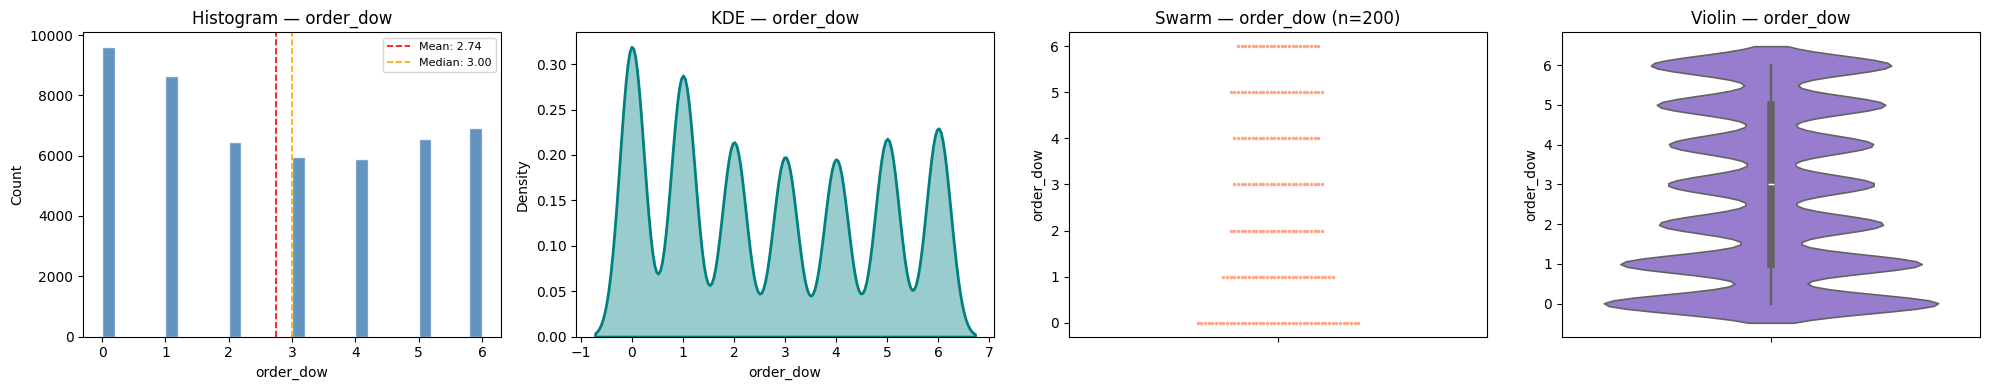

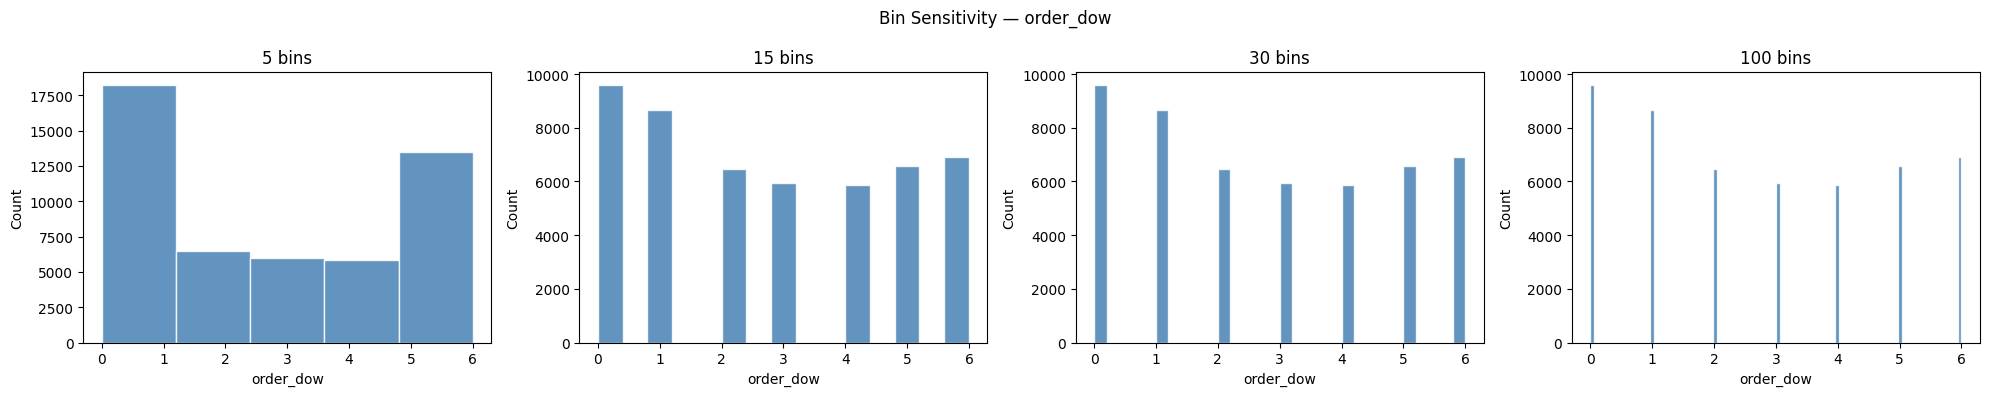

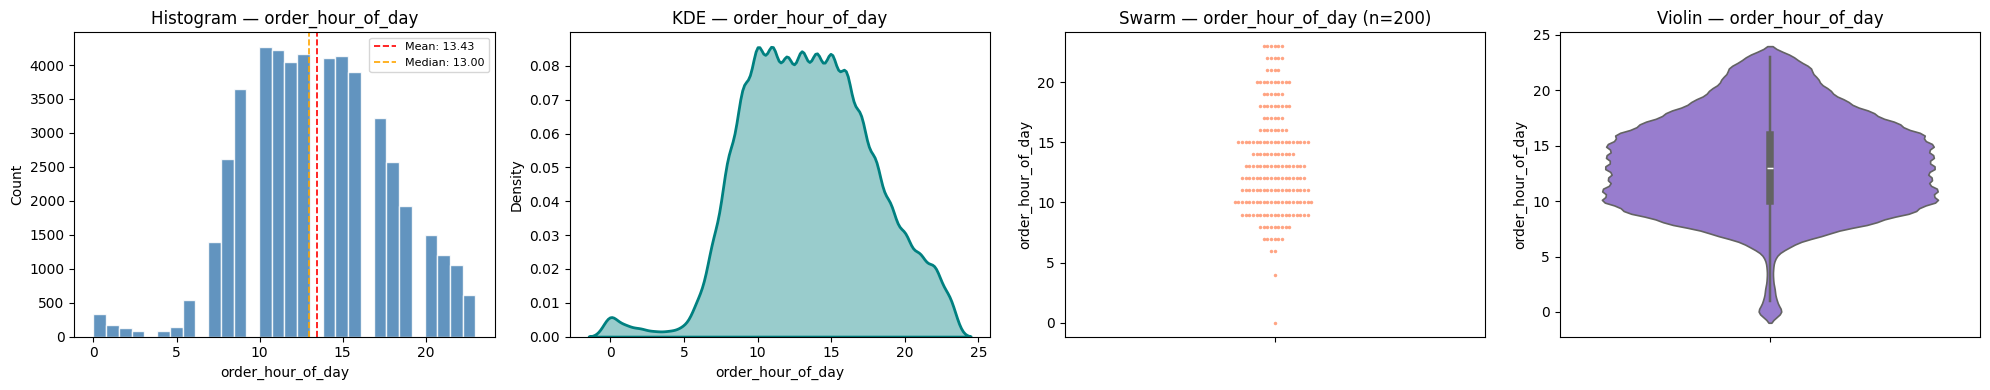

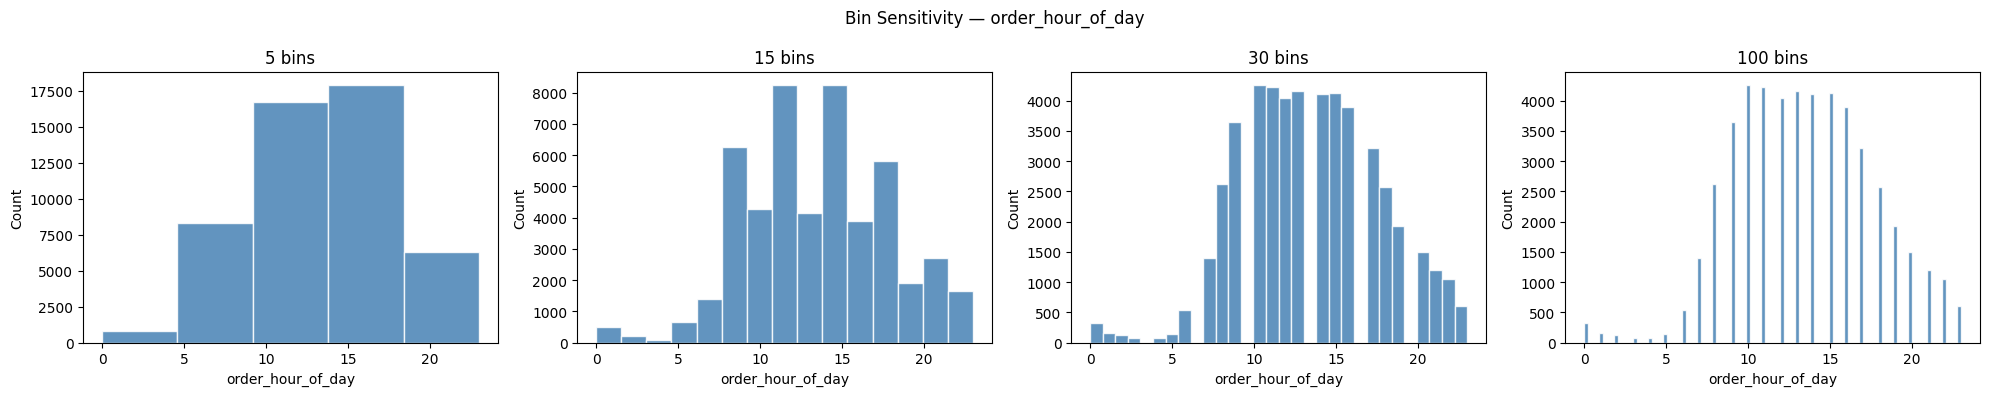

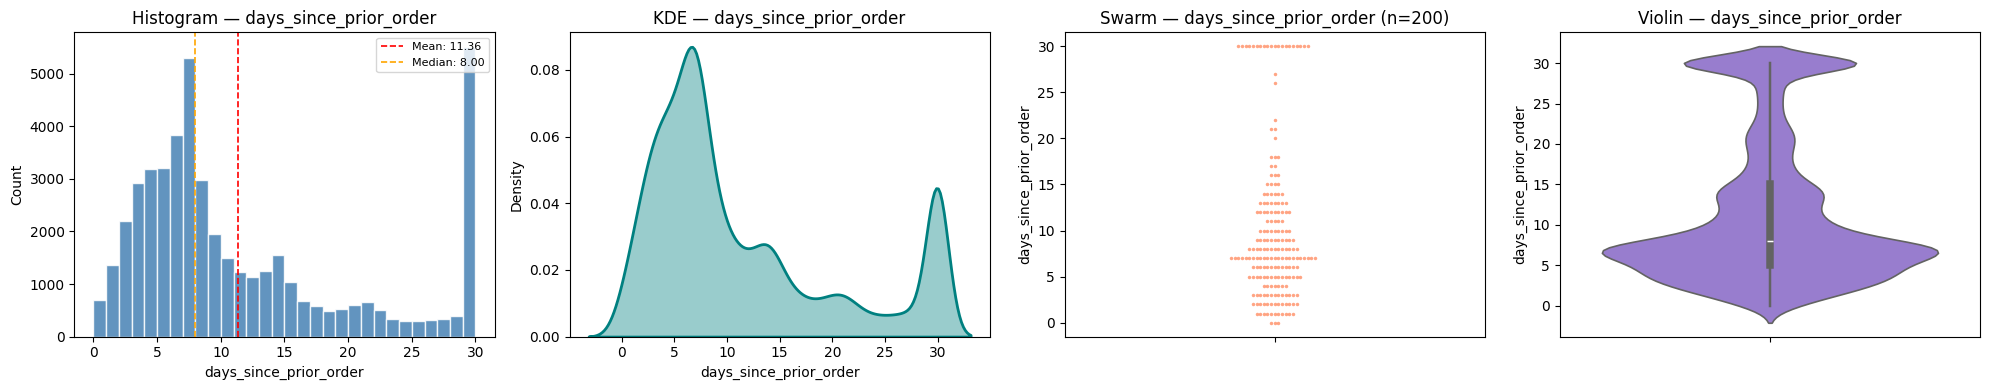

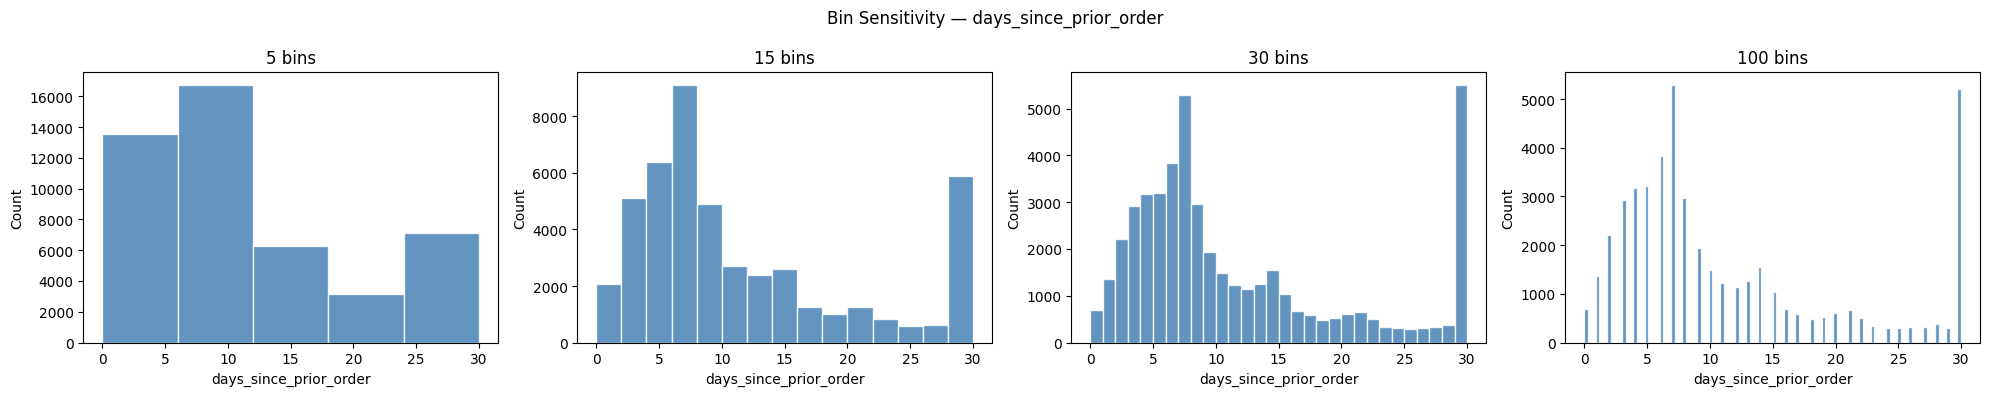

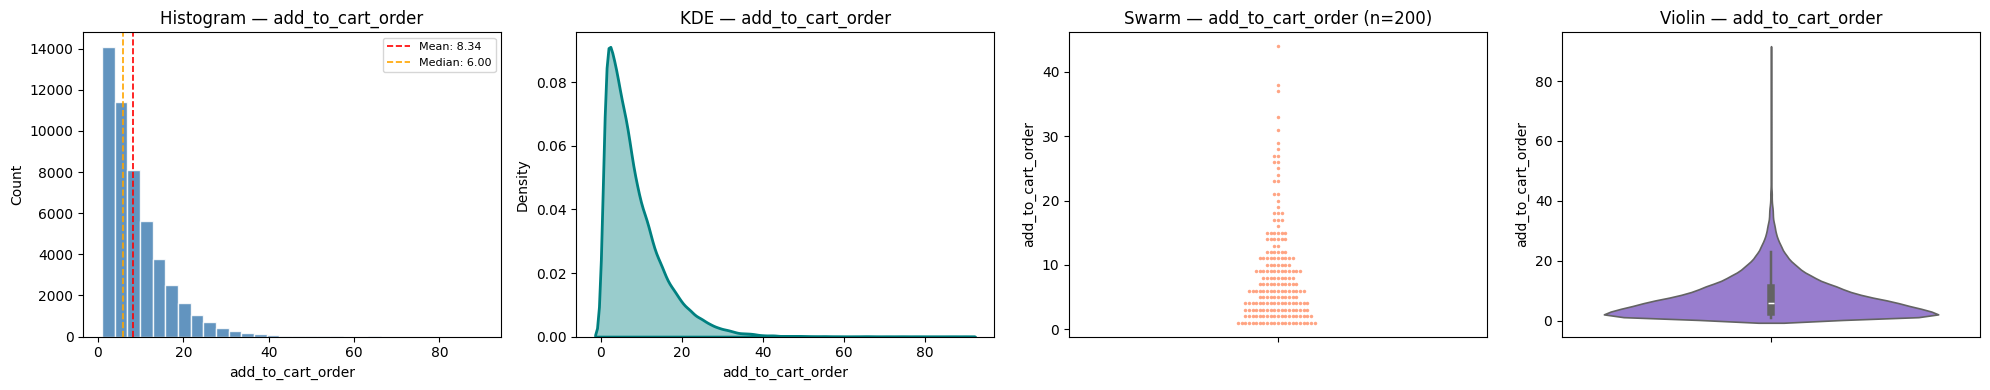

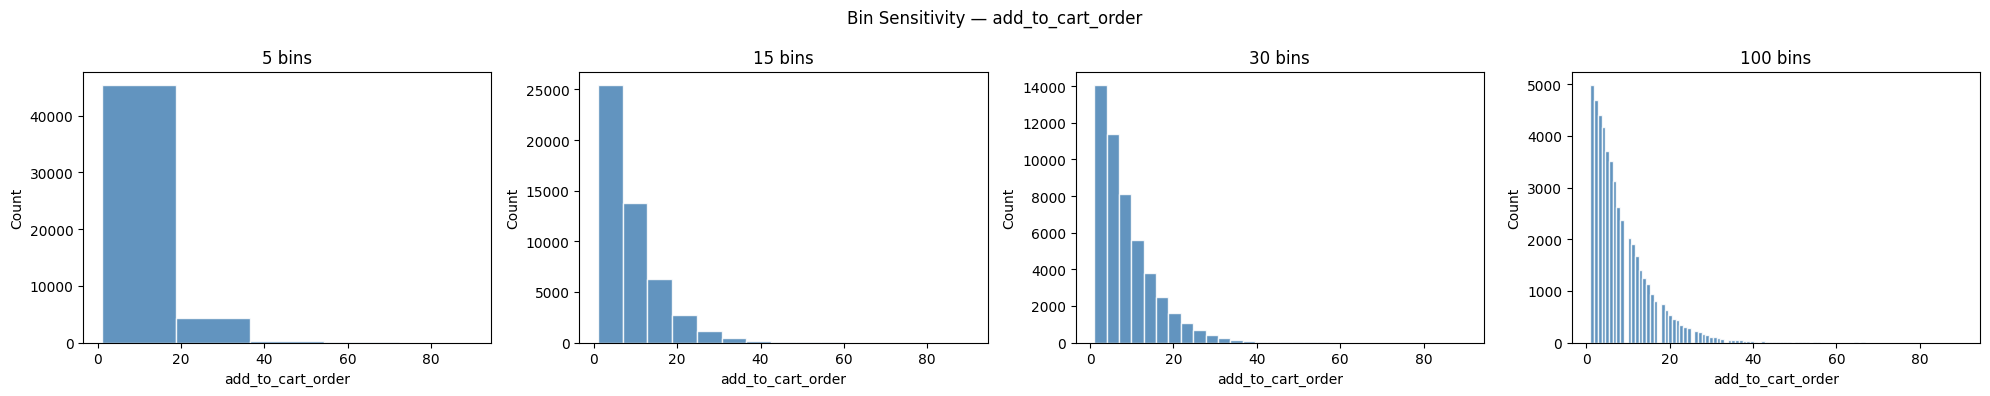

/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


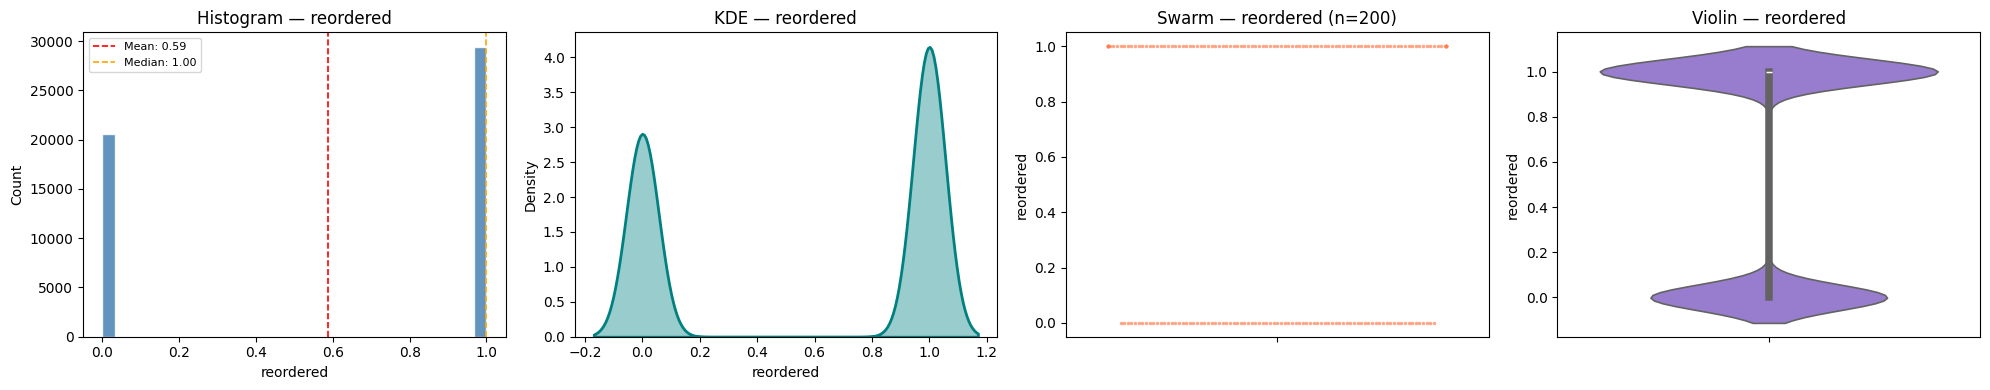

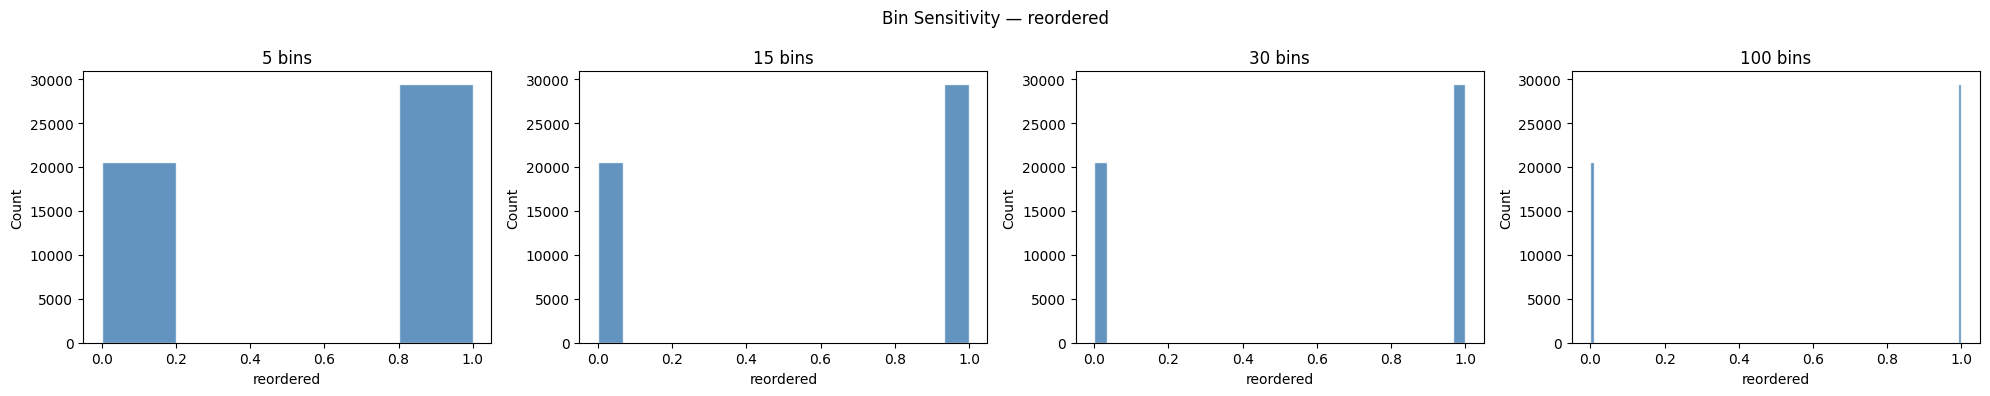


--- Categorical Features ---


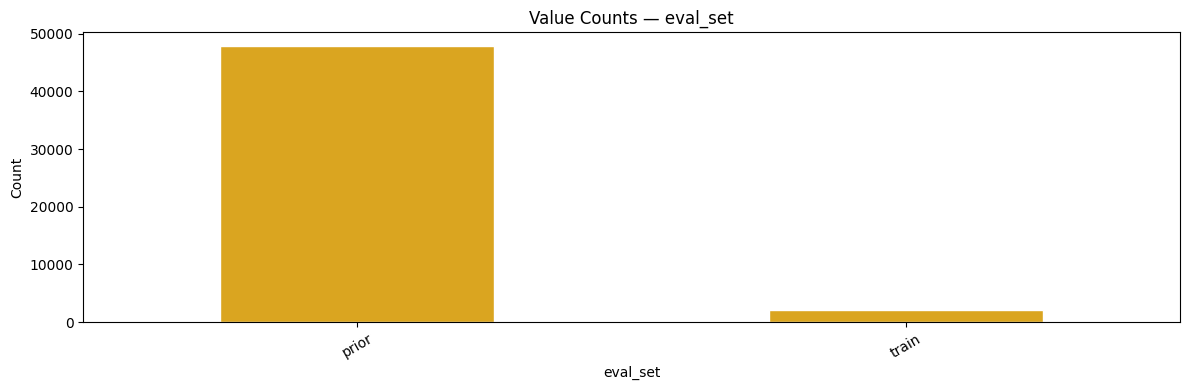

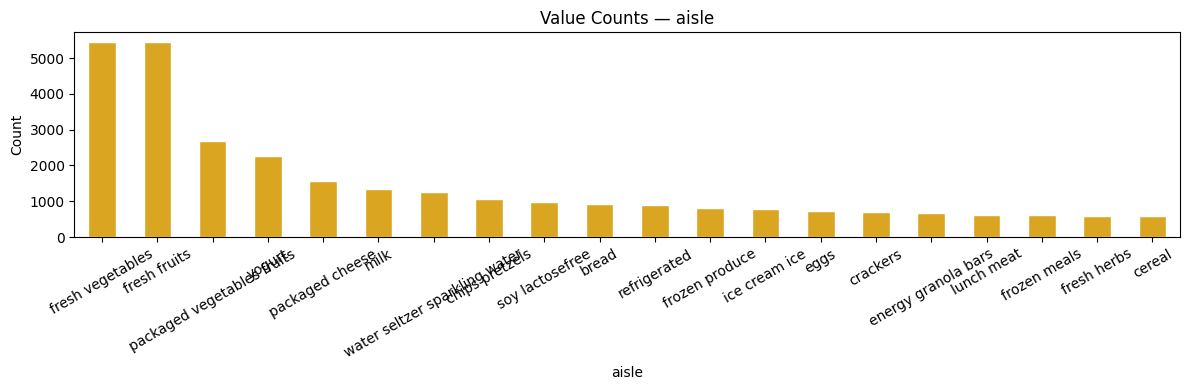

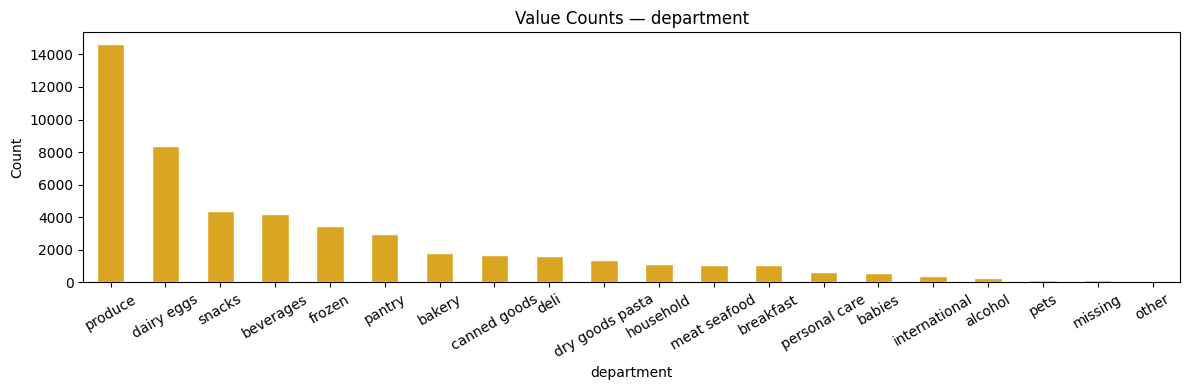


--- Grouped Features ---


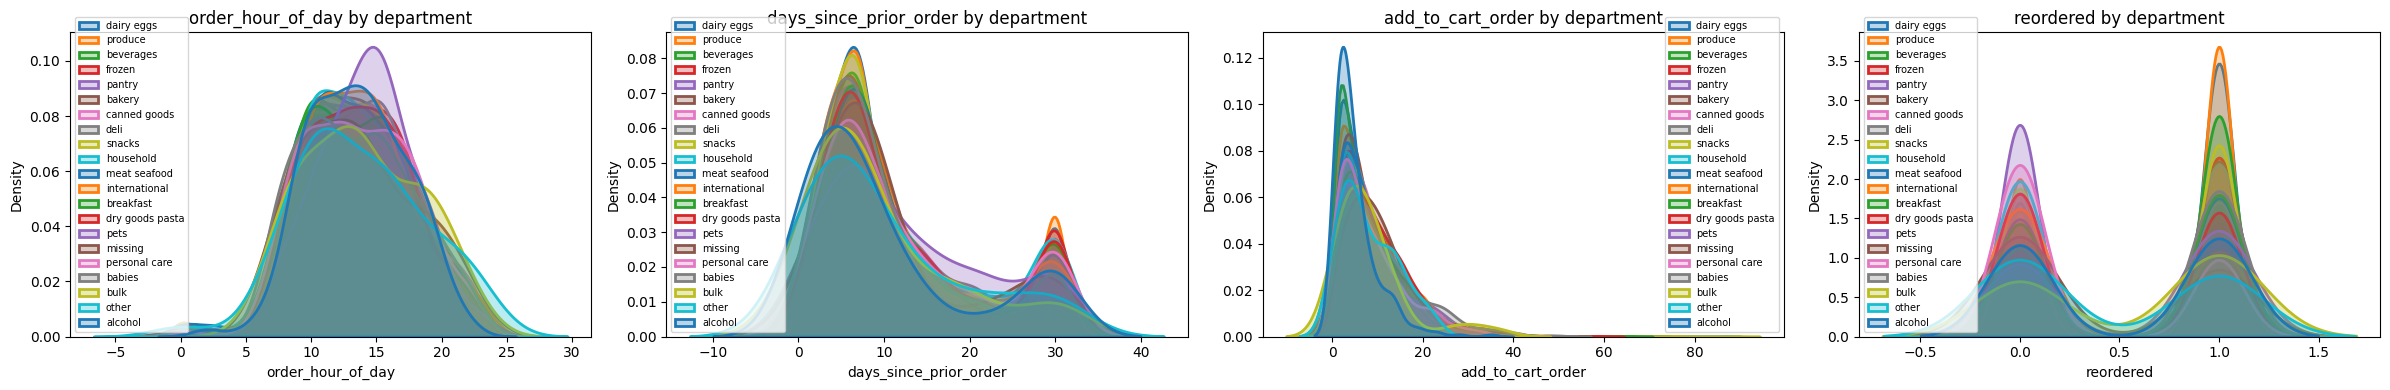

In [12]:
groupings = [
    ('order_hour_of_day', 'department'),
    ('days_since_prior_order', 'department'),
    ('add_to_cart_order', 'department'),
    ('reordered', 'department'),
]
analyze_dataset(df,groupings, dataset_name='Instacart Records')

## Bivariate Analysis

In [22]:
## Bivariate helpers
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_pairplot(df, numeric_cols, hue_col=None, sample_n=1000):
    data = df[numeric_cols + ([hue_col] if hue_col else [])].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    g = sns.pairplot(data, hue=hue_col, plot_kws={'alpha': 0.3, 's': 15},
                     diag_kind='kde', palette='tab10')
    g.fig.suptitle('Pairplot' + (f' by {hue_col}' if hue_col else ''), y=1.02)
    plt.show()


def plot_line_by_time(df, time_col, numeric_col, ax, groupby_col=None, agg='mean'):
    if groupby_col:
        for group, gdf in df.groupby(groupby_col):
            agg_data = gdf.groupby(time_col)[numeric_col].agg(agg).sort_index()
            ax.plot(agg_data.index, agg_data.values, label=str(group), alpha=0.8)
        ax.legend(fontsize=7, title=groupby_col)
    else:
        agg_data = df.groupby(time_col)[numeric_col].agg(agg).sort_index()
        ax.fill_between(agg_data.index, agg_data.values, alpha=0.3, color='steelblue')
        ax.plot(agg_data.index, agg_data.values, color='steelblue', linewidth=2)
    ax.set_title(f'{agg.capitalize()} {numeric_col} by {time_col}')
    ax.set_xlabel(time_col)
    ax.set_ylabel(f'{agg} {numeric_col}')


def plot_correlation_heatmap(df, numeric_cols, ax):
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Matrix')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def plot_boxplot_by_category(df, numeric_col, cat_col, ax, top_n=10):
    top_cats = df[cat_col].value_counts().head(top_n).index
    data = df[df[cat_col].isin(top_cats)]
    sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,
                palette='Set2', order=top_cats)
    ax.set_title(f'{numeric_col} by {cat_col} (top {top_n})')
    ax.tick_params(axis='x', rotation=40)


def plot_grouped_bar(df, cat_col, numeric_col, ax, top_n=10, agg='mean'):
    grouped = df.groupby(cat_col)[numeric_col].agg(agg).sort_values(ascending=False).head(top_n)
    grouped.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{agg.capitalize()} {numeric_col} by {cat_col} (top {top_n})')
    ax.set_xlabel(cat_col)
    ax.set_ylabel(f'{agg} {numeric_col}')
    ax.tick_params(axis='x', rotation=40)


def plot_heatmap_two_categoricals(df, col_x, col_y, ax, top_n=10):
    top_x = df[col_x].value_counts().head(top_n).index
    top_y = df[col_y].value_counts().head(top_n).index
    pivot = df[df[col_x].isin(top_x) & df[col_y].isin(top_y)]\
              .groupby([col_y, col_x]).size().unstack(fill_value=0)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Count Heatmap: {col_y} vs {col_x}')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def plot_scatter(df, col_x, col_y, ax, sample_n=2000, hue_col=None):
    data = df[[col_x, col_y] + ([hue_col] if hue_col else [])].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    sns.scatterplot(data=data, x=col_x, y=col_y, ax=ax,
                    hue=hue_col, alpha=0.4, s=20,
                    palette='tab10' if hue_col else None)
    ax.set_title(f'{col_x} vs {col_y}' + (f' (by {hue_col})' if hue_col else ''))


def analyze_dataset_bi_variate(
    df,
    numeric_cols,            # list of numeric cols for correlation heatmap
    boxplot_pairs,           # list of (numeric_col, cat_col)
    grouped_bar_pairs,       # list of (cat_col, numeric_col, agg) — agg: 'mean' | 'sum' | 'median'
    heatmap_pairs,           # list of (col_x, col_y) — two categoricals
    scatter_pairs,           # list of (col_x, col_y) or (col_x, col_y, hue_col)
    pairplot_cols=None,      # (numeric_cols_list, optional hue_col)
    line_pairs=None,          # list of (time_col, numeric_col, agg) or (time_col, numeric_col, agg, groupby_col)
    dataset_name='Dataset'
):
    print(f"{'='*100}")
    print(f"  {dataset_name} — Bivariate Analysis")
    print(f"{'='*100}")

    # Correlation heatmap
    if numeric_cols:
        print("\n--- Correlation Matrix ---")
        fig, ax = plt.subplots(figsize=(10, 8))
        plot_correlation_heatmap(df, numeric_cols, ax)
        plt.tight_layout()
        plt.show()

    # Boxplots
    if boxplot_pairs:
        print("\n--- Boxplots ---")
        for numeric_col, cat_col in boxplot_pairs:
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_boxplot_by_category(df, numeric_col, cat_col, ax)
            plt.tight_layout()
            plt.show()

    # Grouped bar charts
    if grouped_bar_pairs:
        print("\n--- Grouped Bar Charts ---")
        for cat_col, numeric_col, agg in grouped_bar_pairs:
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_grouped_bar(df, cat_col, numeric_col, ax, agg=agg)
            plt.tight_layout()
            plt.show()

    # Two-categorical heatmaps
    if heatmap_pairs:
        print("\n--- Category Heatmaps ---")
        for col_x, col_y in heatmap_pairs:
            fig, ax = plt.subplots(figsize=(12, 6))
            plot_heatmap_two_categoricals(df, col_x, col_y, ax)
            plt.tight_layout()
            plt.show()

    # Scatter plots
    if scatter_pairs:
        print("\n--- Scatter Plots ---")
        for pair in scatter_pairs:
            col_x, col_y = pair[0], pair[1]
            hue_col = pair[2] if len(pair) == 3 else None
            fig, ax = plt.subplots(figsize=(10, 6))
            plot_scatter(df, col_x, col_y, ax, hue_col=hue_col)
            plt.tight_layout()
            plt.show()
    # Pairplot
    if pairplot_cols:
        print("\n--- Pairplot ---")
        cols, hue_col = pairplot_cols[0], pairplot_cols[1] if len(pairplot_cols) > 1 else None
        plot_pairplot(df, cols, hue_col=hue_col)

    # Line / area graphs
    if line_pairs:
        print("\n--- Line / Area Graphs ---")
        for pair in line_pairs:
            time_col, numeric_col, agg = pair[0], pair[1], pair[2]
            groupby_col = pair[3] if len(pair) == 4 else None
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_line_by_time(df, time_col, numeric_col, ax, groupby_col=groupby_col, agg=agg)
            plt.tight_layout()
            plt.show()

  Instacart Records — Bivariate Analysis

--- Correlation Matrix ---


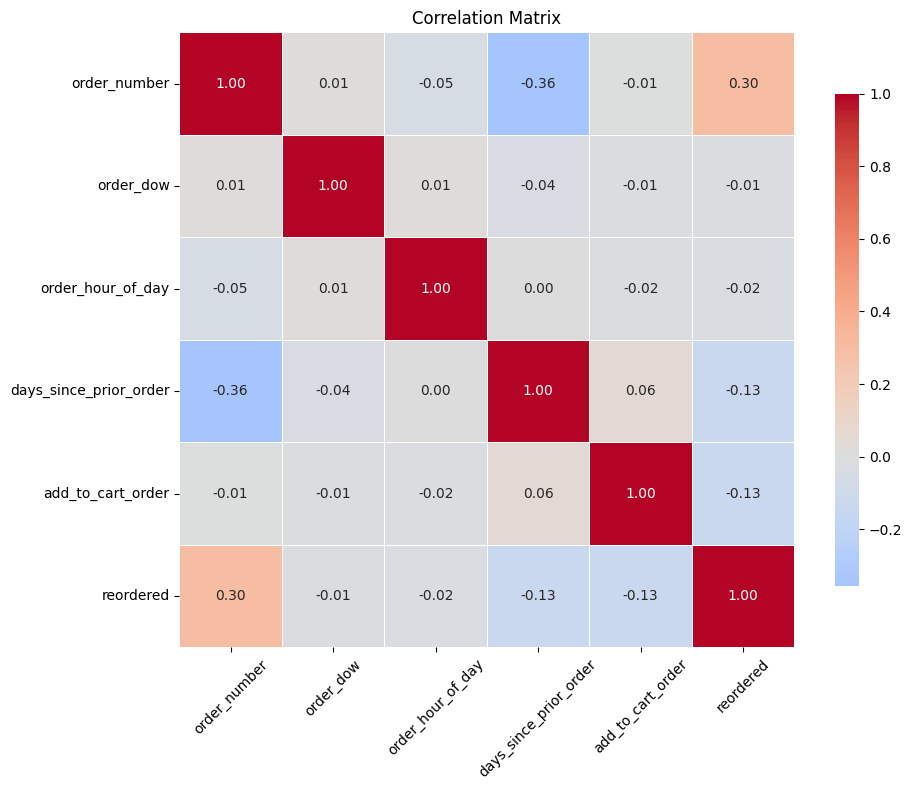


--- Boxplots ---


/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_67514/1659448462.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,


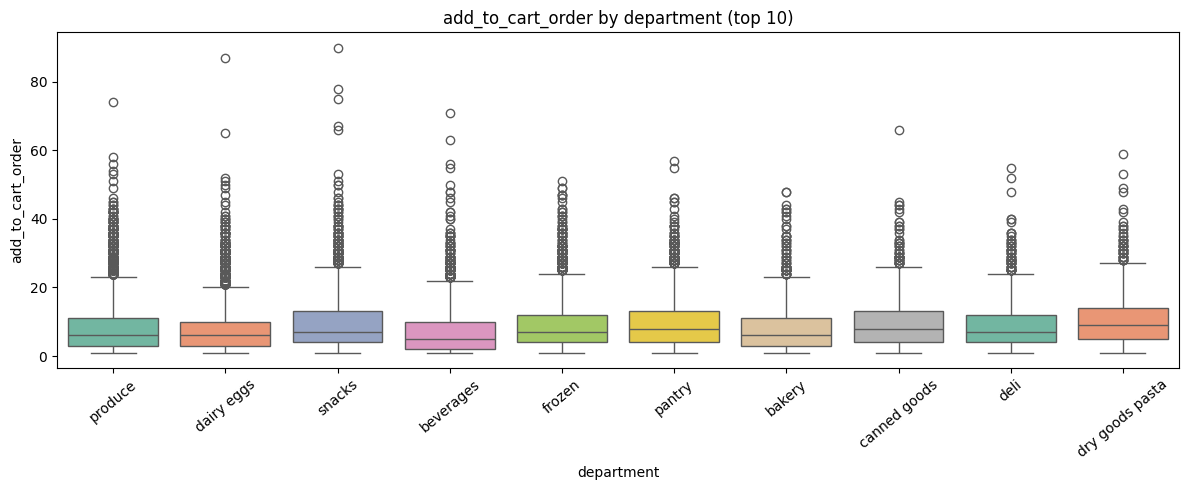

/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_67514/1659448462.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,


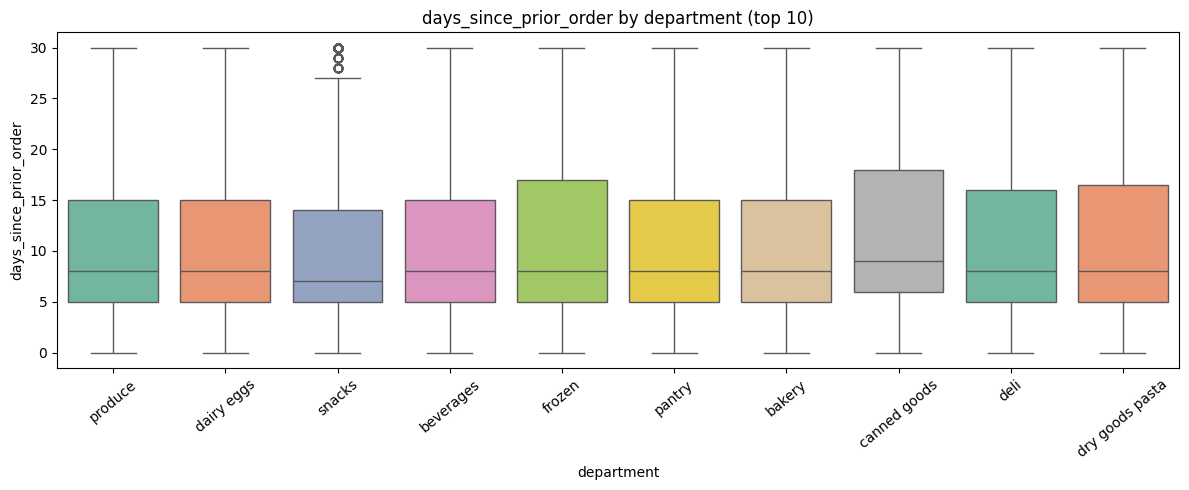


--- Grouped Bar Charts ---


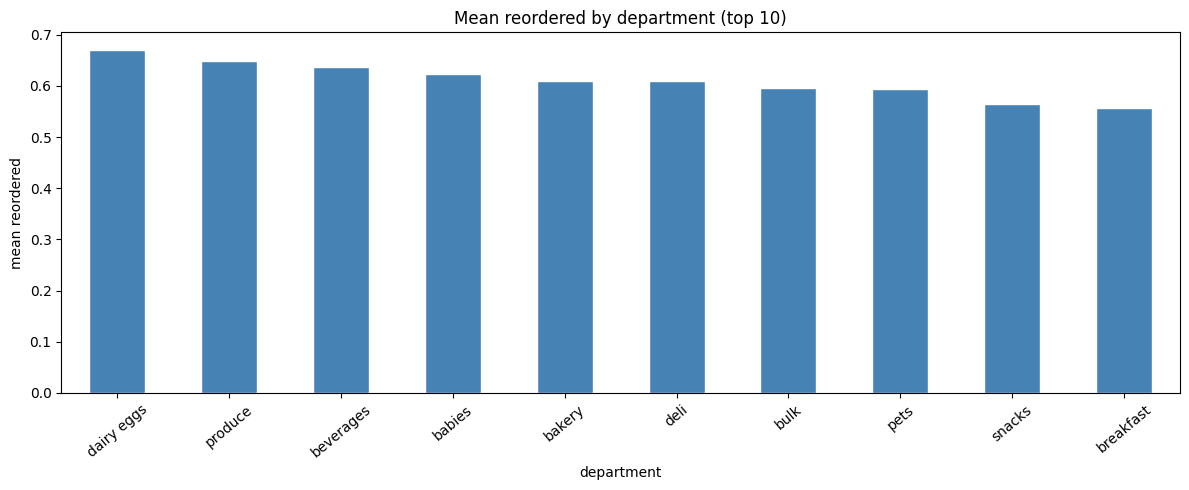

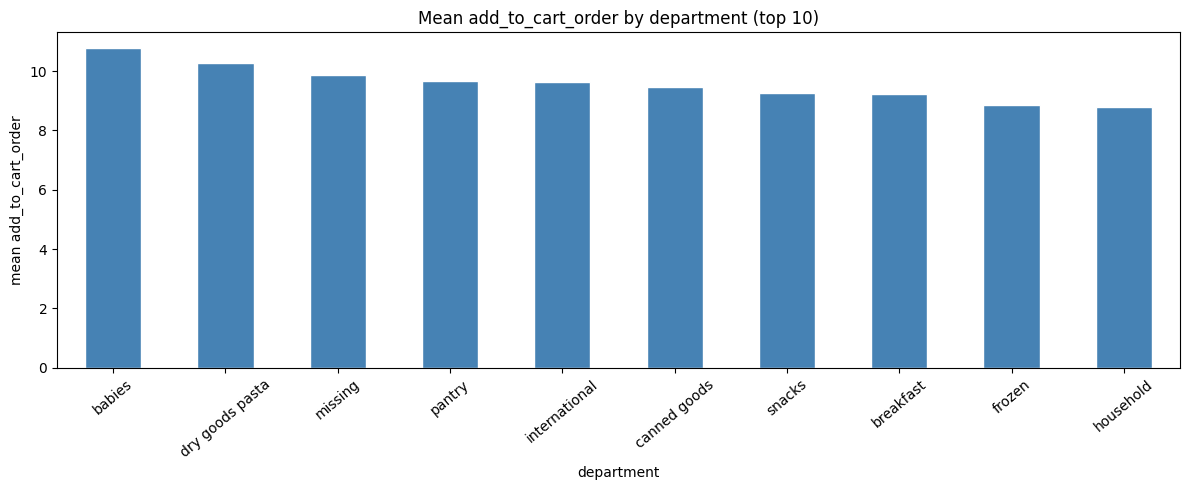


--- Category Heatmaps ---


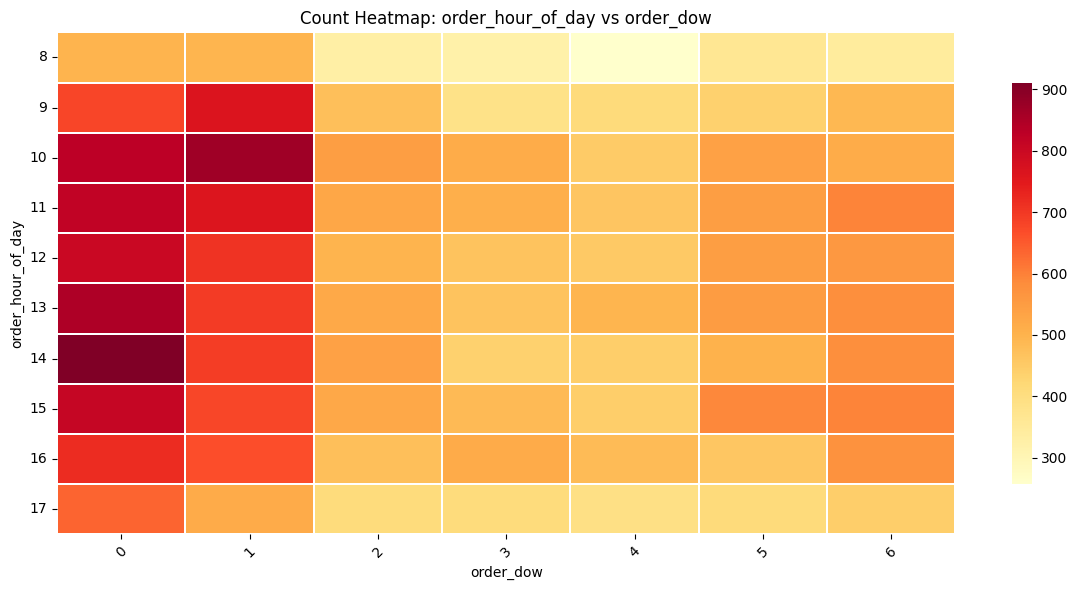


--- Scatter Plots ---


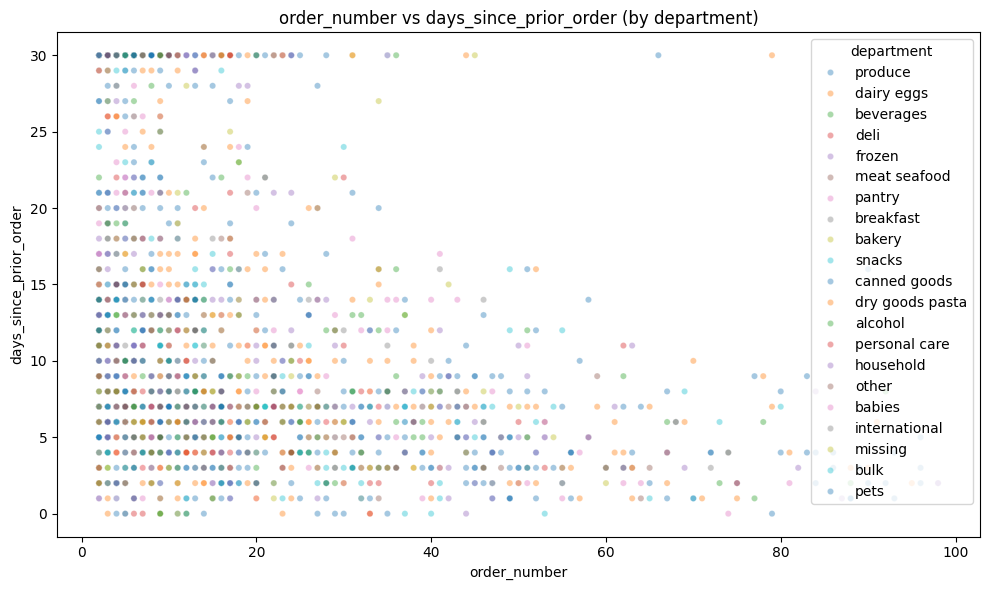


--- Pairplot ---


/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
/Users/es864k/School/BU/venv/lib/python3

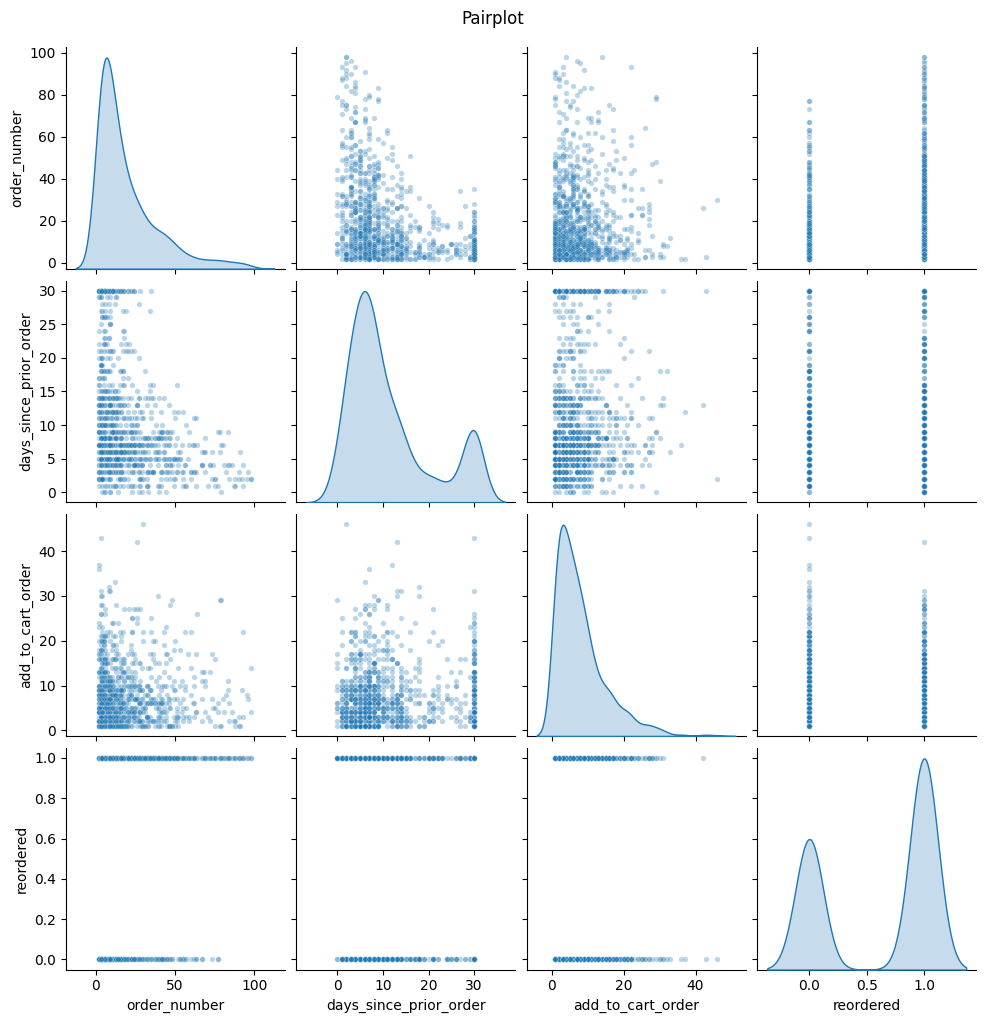


--- Line / Area Graphs ---


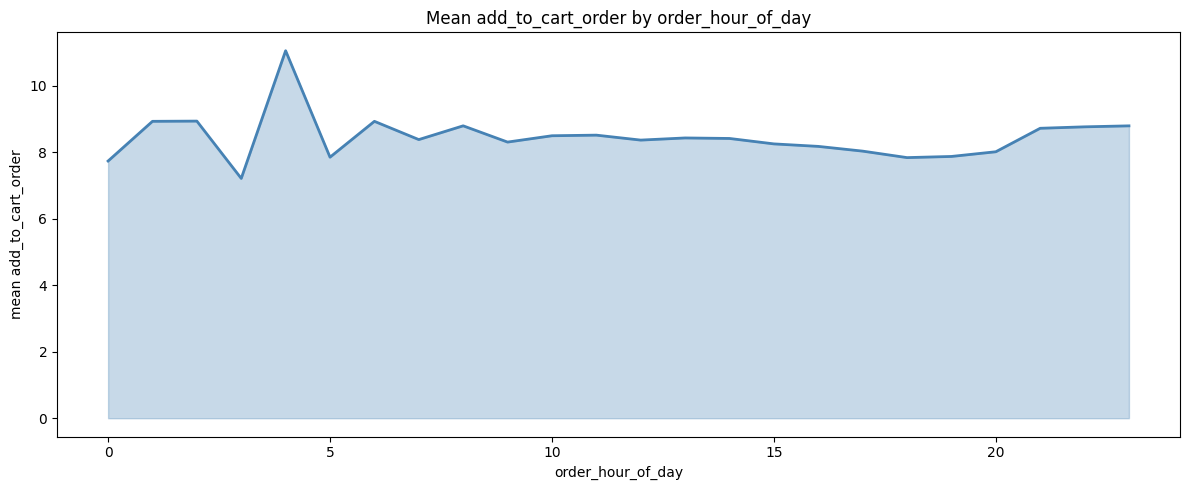

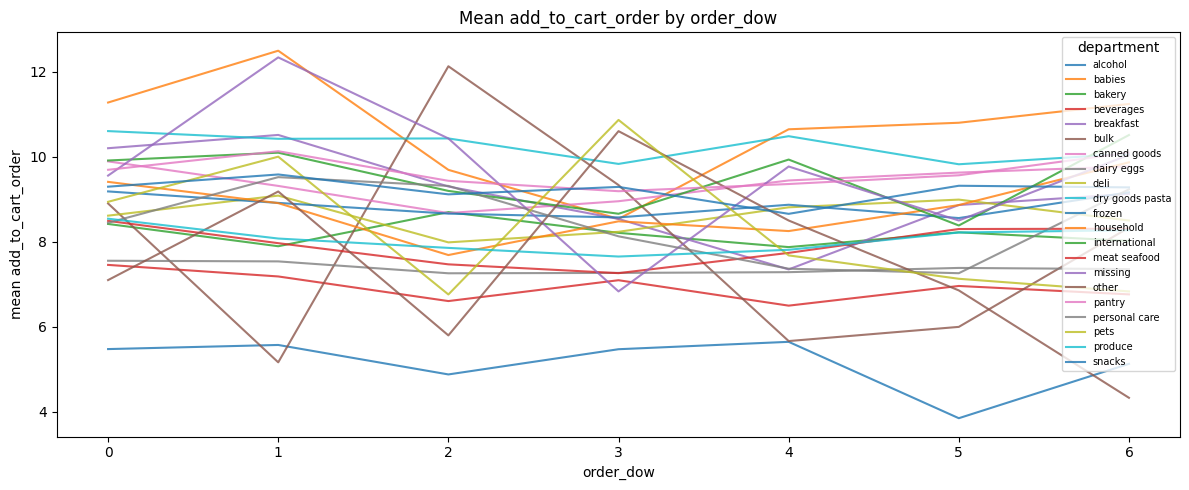

In [24]:
# Instacart bivariate analysis
# numeric cols to correlate (exclude IDs)
numeric_cols = [
    'order_number', 'order_dow', 'order_hour_of_day',
    'days_since_prior_order', 'add_to_cart_order', 'reordered'
]

# (numeric_col, cat_col)
boxplot_pairs = [
    ('add_to_cart_order', 'department'),   # basket depth by department
    ('days_since_prior_order', 'department'),
]

# (cat_col, numeric_col, agg)
grouped_bar_pairs = [
    ('department', 'reordered', 'mean'),   # reorder rate by department
    ('department', 'add_to_cart_order', 'mean'),
]

# (col_x, col_y) — both categorical or low-cardinality numeric
heatmap_pairs = [
    ('order_dow', 'order_hour_of_day'),    # shopping time patterns
]

# (col_x, col_y) or (col_x, col_y, hue_col)
scatter_pairs = [
    ('order_number', 'days_since_prior_order', 'department'),
]

pairplot_cols = (
    ['order_number', 'days_since_prior_order', 'add_to_cart_order', 'reordered'],
    None  # no hue — too many departments, would be noisy
)

line_pairs = [
    ('order_hour_of_day', 'add_to_cart_order', 'mean'),           # basket size across hours
    ('order_dow', 'add_to_cart_order', 'mean', 'department'),     # by day + department
]

analyze_dataset_bi_variate(
    df,
    numeric_cols=numeric_cols,
    boxplot_pairs=boxplot_pairs,
    grouped_bar_pairs=grouped_bar_pairs,
    heatmap_pairs=heatmap_pairs,
    scatter_pairs=scatter_pairs,
    pairplot_cols=pairplot_cols,
    line_pairs=line_pairs,
    dataset_name='Instacart Records'
)

## Figures Export

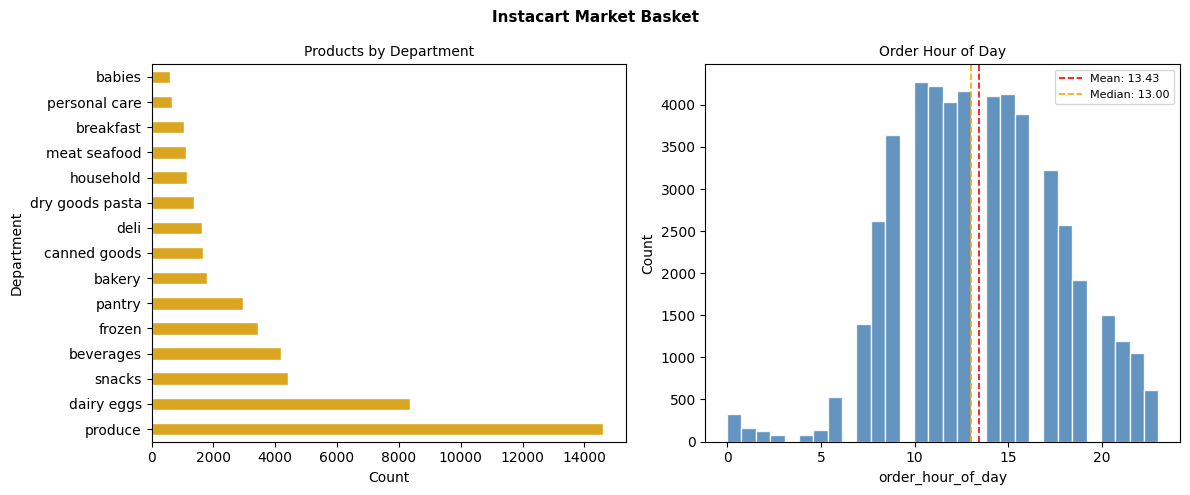

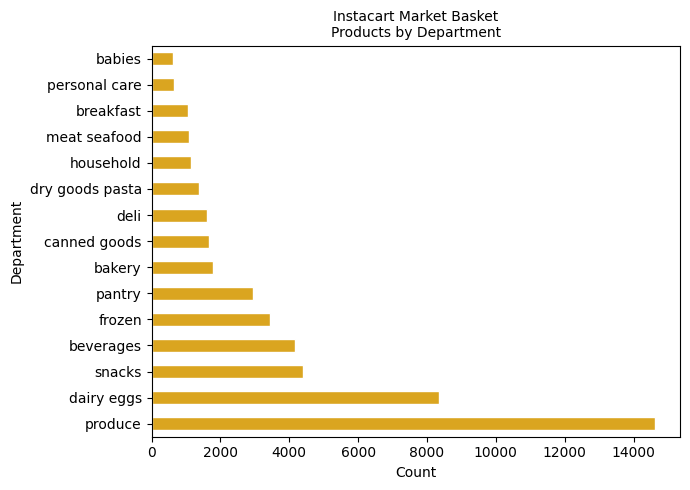

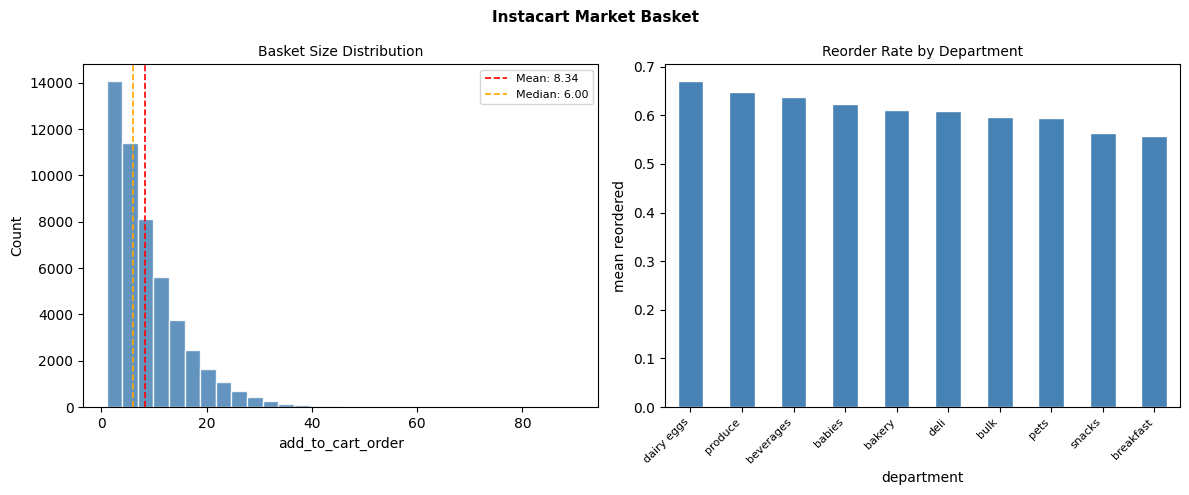

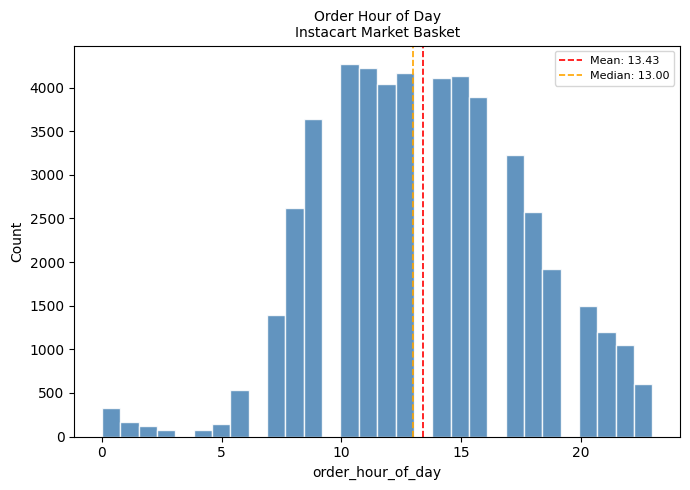

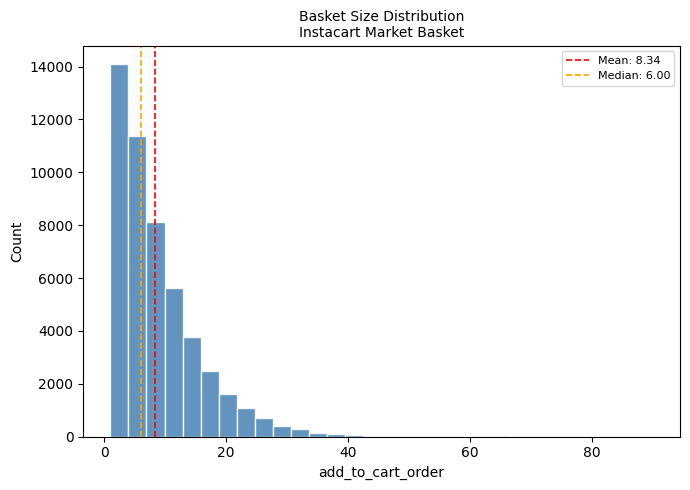

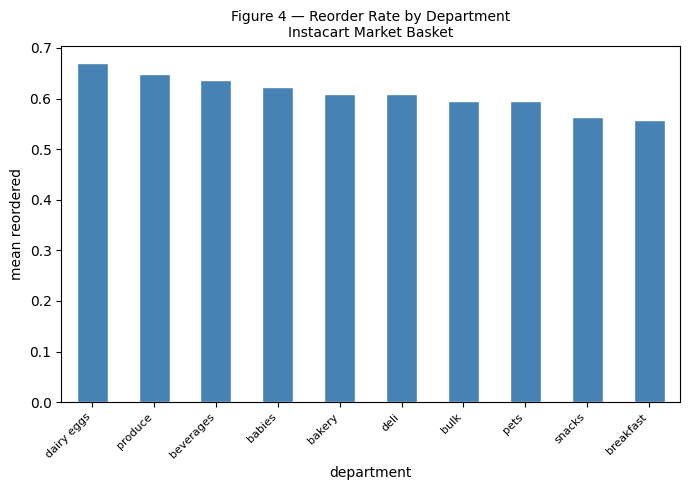

/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_67514/1659448462.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,
/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_67514/922386122.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha=ha, fontsize=fontsize)


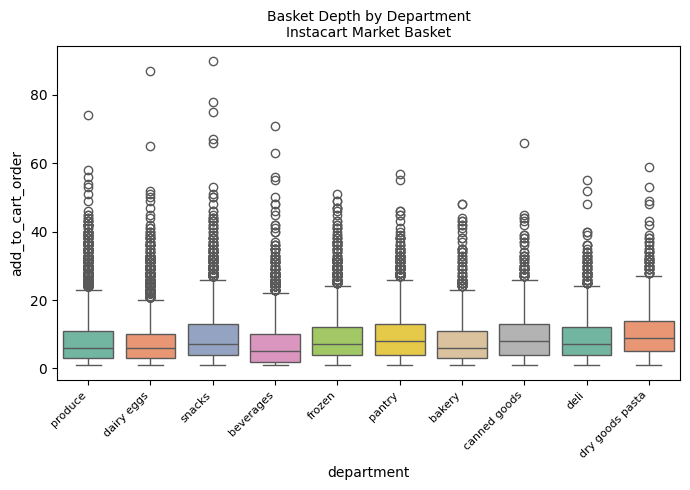

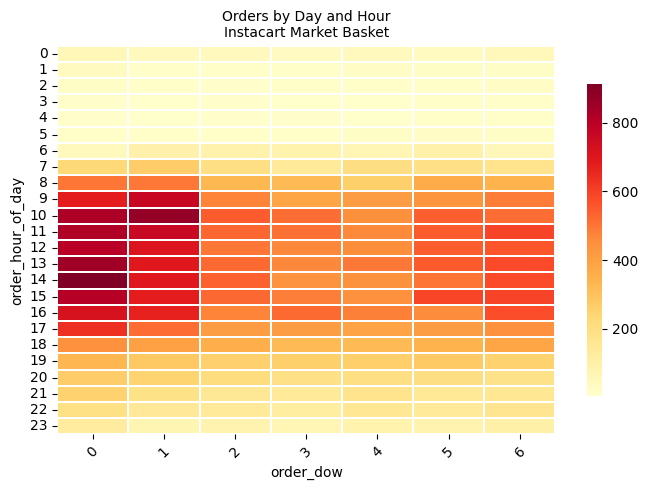

Figures saved to ./figures/ [Instacart Market Basket]


In [34]:
import os
os.makedirs('figures', exist_ok=True)

# ── Dataset label (change this per notebook) ──────────────────────
DATASET_TITLE = "Instacart Market Basket"
# ──────────────────────────────────────────────────────────────────



fig_size = (7, 5)  # slightly wider to give labels room


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')






def clean_labels(ax, rotation=45, ha='right', fontsize=8):
    ax.tick_params(axis='x', rotation=rotation)
    ax.set_xticklabels(ax.get_xticklabels(), ha=ha, fontsize=fontsize)
    plt.tight_layout()


    


# Left — Department distribution
df['department'].value_counts().head(15).plot(
    kind='barh', ax=axes[0], color='goldenrod', edgecolor='white')
axes[0].set_title('Products by Department', fontsize=10)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Department')

# Right — Order hour of day
plot_histogram(df, 'order_hour_of_day', axes[1])
axes[1].set_title('Order Hour of Day', fontsize=10)

plt.tight_layout()
plt.savefig('figures/fig1_instacart_combined.png', dpi=150)
plt.show()

# Fig 1 — Department distribution
fig, ax = plt.subplots(figsize=fig_size)
df['department'].value_counts().head(15).plot(kind='barh', ax=ax, color='goldenrod', edgecolor='white')
ax.set_title(f'{DATASET_TITLE}\nProducts by Department', fontsize=10)
ax.set_xlabel('Count')
ax.set_ylabel('Department')
plt.tight_layout()
plt.savefig('figures/fig1_instacart_department_distribution.png', dpi=150)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')

# Left — Basket size
plot_histogram(df, 'add_to_cart_order', axes[0])
axes[0].set_title('Basket Size Distribution', fontsize=10)

# Right — Reorder rate by department
plot_grouped_bar(df, 'department', 'reordered', axes[1], agg='mean')
axes[1].set_title('Reorder Rate by Department', fontsize=10)
clean_labels(axes[1])

plt.tight_layout()
plt.savefig('figures/fig2_instacart_basket_reorder.png', dpi=150)
plt.show()

# Fig 2 — Order hour of day histogram
fig, ax = plt.subplots(figsize=fig_size)
plot_histogram(df, 'order_hour_of_day', ax)
ax.set_title(f'Order Hour of Day\n{DATASET_TITLE}', fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig2_instacart_order_hour.png', dpi=150)
plt.show()

# Fig 3 — Add to cart order distribution
fig, ax = plt.subplots(figsize=fig_size)
plot_histogram(df, 'add_to_cart_order', ax)
ax.set_title(f'Basket Size Distribution\n{DATASET_TITLE}', fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig3_instacart_add_to_cart.png', dpi=150)
plt.show()

# Fig 4 — Reorder rate by department
fig, ax = plt.subplots(figsize=fig_size)
plot_grouped_bar(df, 'department', 'reordered', ax, agg='mean')
ax.set_title(f'Figure 4 — Reorder Rate by Department\n{DATASET_TITLE}', fontsize=10)
clean_labels(ax)
plt.savefig('figures/fig4_instacart_reorder_by_dept.png', dpi=150)
plt.show()

# Fig 5 — Basket depth by department
fig, ax = plt.subplots(figsize=fig_size)
plot_boxplot_by_category(df, 'add_to_cart_order', 'department', ax)
ax.set_title(f'Basket Depth by Department\n{DATASET_TITLE}', fontsize=10)
clean_labels(ax)
plt.savefig('figures/fig5_instacart_basket_depth_by_dept.png', dpi=150)
plt.show()

# Fig 6 — Shopping time heatmap
fig, ax = plt.subplots(figsize=fig_size)
plot_heatmap_two_categoricals(df, 'order_dow', 'order_hour_of_day', ax, top_n=24)
ax.set_title(f'Orders by Day and Hour\n{DATASET_TITLE}', fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig6_instacart_day_hour_heatmap.png', dpi=150)
plt.show()

print(f"Figures saved to ./figures/ [{DATASET_TITLE}]")